<a href="https://colab.research.google.com/github/cedrick8sangwa/Metallurgy-data-analytics/blob/main/slag_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Generate Synthetic Metallurgical Dataset
np.random.seed(42)
n_batches = 100

fixed_carbon = np.random.uniform(82.0, 89.0, n_batches)  # % Fixed Carbon in Coke
ash_content = np.random.uniform(9.0, 15.0, n_batches)  # % Ash Content in Coke
temp_c = np.random.uniform(1220, 1310, n_batches)  # Furnace Slag Temp (°C)

# Metallurgical physical relationship:
# High ash -> high viscosity -> high mechanical Cu entrainment
# Low fixed carbon -> poor reduction -> high chemical Cu loss (Cu2O)
cu_loss_chem = np.maximum(0.2, 3.5 - 0.035 * fixed_carbon)
cu_loss_mech = np.maximum(0.1, 0.12 * ash_content - 0.001 * (temp_c - 1200))
noise = np.random.normal(0, 0.08, n_batches)

slag_cu_pct = np.clip(cu_loss_chem + cu_loss_mech + noise, 0.4, 2.5)

df = pd.DataFrame({
    'Batch_ID': [f'BAT-{i+101:03d}' for i in range(n_batches)],
    'Coke_Fixed_Carbon_Pct': np.round(fixed_carbon, 2),
    'Coke_Ash_Pct': np.round(ash_content, 2),
    'Slag_Temp_C': np.round(temp_c, 1),
    'Slag_Cu_Pct': np.round(slag_cu_pct, 2),
})

# Save synthetic dataset to CSV
df.to_csv('copper_slag_data.csv', index=False)
print("✅ Dataset saved to 'copper_slag_data.csv'")

# 2. Plotting Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression Analysis (Coke Ash vs Slag Cu Loss)
sns.regplot(
    data=df,
    x='Coke_Ash_Pct',
    y='Slag_Cu_Pct',
    ax=axes[0],
    color='#1f77b4',
    scatter_kws={'alpha': 0.7, 's': 40},
    line_kws={'color': '#d62728', 'linewidth': 2},
)
axes[0].set_title(
    'Impact of Coke Ash Content on Copper Loss in Slag',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('Coke Ash Content (%)', fontsize=10)
axes[0].set_ylabel('Copper Loss in Slag (% Cu)', fontsize=10)
axes[0].axhline(
    y=0.8, color='green', linestyle='--', label='Target Max Cu Loss (0.8%)'
)
axes[0].legend(loc='upper left')

# Plot 2: Statistical Process Control (SPC X-bar Chart)
mean_cu = df['Slag_Cu_Pct'].mean()
std_cu = df['Slag_Cu_Pct'].std()
ucl = mean_cu + 3 * std_cu
lcl = max(0, mean_cu - 3 * std_cu)

axes[1].plot(
    df.index,
    df['Slag_Cu_Pct'],
    marker='o',
    markersize=4,
    color='#2ca02c',
    linewidth=1.5,
    label='% Cu per Batch',
)
axes[1].axhline(
    y=mean_cu, color='blue', linestyle='-', label=f'Center Line ({mean_cu:.2f}%)'
)
axes[1].axhline(
    y=ucl, color='red', linestyle='--', label=f'UCL (+3σ: {ucl:.2f}%)'
)
axes[1].axhline(
    y=lcl, color='orange', linestyle='--', label=f'LCL (-3σ: {lcl:.2f}%)'
)
axes[1].set_title(
    'Statistical Process Control (SPC): Slag Cu % Monitoring',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Batch Sequence', fontsize=10)
axes[1].set_ylabel('Copper Loss (% Cu)', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()

# Save Figures
output_img = 'slag_analysis_spc_charts.png'
plt.savefig(output_img, dpi=300)
plt.close()
print(f"✅ Charts successfully generated and saved to '{output_img}'")

✅ Dataset saved to 'copper_slag_data.csv'
✅ Charts successfully generated and saved to 'slag_analysis_spc_charts.png'


✅ Dataset saved to 'copper_slag_data.csv'


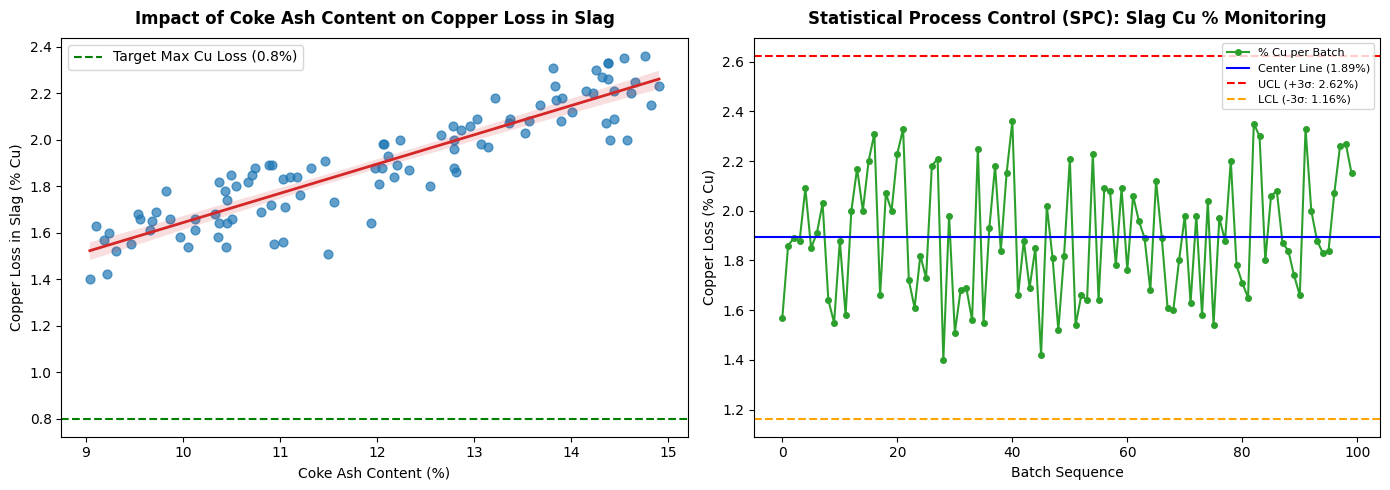

In [12]:

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns

# 1. Generate Synthetic Metallurgical Dataset
np.random.seed(42)
n_batches = 100

fixed_carbon = np.random.uniform(82.0, 89.0, n_batches)  # % Fixed Carbon in Coke
ash_content = np.random.uniform(9.0, 15.0, n_batches)  # % Ash Content in Coke
temp_c = np.random.uniform(1220, 1310, n_batches)  # Furnace Slag Temp (°C)

# Metallurgical physical relationship:
# High ash -> high viscosity -> high mechanical Cu entrainment
# Low fixed carbon -> poor reduction -> high chemical Cu loss (Cu2O)
cu_loss_chem = np.maximum(0.2, 3.5 - 0.035 * fixed_carbon)
cu_loss_mech = np.maximum(0.1, 0.12 * ash_content - 0.001 * (temp_c - 1200))
noise = np.random.normal(0, 0.08, n_batches)

slag_cu_pct = np.clip(cu_loss_chem + cu_loss_mech + noise, 0.4, 2.5)

df = pd.DataFrame({
    'Batch_ID': [f'BAT-{i+101:03d}' for i in range(n_batches)],
    'Coke_Fixed_Carbon_Pct': np.round(fixed_carbon, 2),
    'Coke_Ash_Pct': np.round(ash_content, 2),
    'Slag_Temp_C': np.round(temp_c, 1),
    'Slag_Cu_Pct': np.round(slag_cu_pct, 2),
})

# Save synthetic dataset to CSV
df.to_csv('copper_slag_data.csv', index=False)
print("✅ Dataset saved to 'copper_slag_data.csv'")

# 2. Plotting Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression Analysis (Coke Ash vs Slag Cu Loss)
sns.regplot(
    data=df,
    x='Coke_Ash_Pct',
    y='Slag_Cu_Pct',
    ax=axes[0],
    color='#1f77b4',
    scatter_kws={'alpha': 0.7, 's': 40},
    line_kws={'color': '#d62728', 'linewidth': 2},
)
axes[0].set_title(
    'Impact of Coke Ash Content on Copper Loss in Slag',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[0].set_xlabel('Coke Ash Content (%)', fontsize=10)
axes[0].set_ylabel('Copper Loss in Slag (% Cu)', fontsize=10)
axes[0].axhline(
    y=0.8, color='green', linestyle='--', label='Target Max Cu Loss (0.8%)'
)
axes[0].legend(loc='upper left')

# Plot 2: Statistical Process Control (SPC X-bar Chart)
mean_cu = df['Slag_Cu_Pct'].mean()
std_cu = df['Slag_Cu_Pct'].std()
ucl = mean_cu + 3 * std_cu
lcl = max(0, mean_cu - 3 * std_cu)

axes[1].plot(
    df.index,
    df['Slag_Cu_Pct'],
    marker='o',
    markersize=4,
    color='#2ca02c',
    linewidth=1.5,
    label='% Cu per Batch',
)
axes[1].axhline(
    y=mean_cu, color='blue', linestyle='-', label=f'Center Line ({mean_cu:.2f}%)'
)
axes[1].axhline(
    y=ucl, color='red', linestyle='--', label=f'UCL (+3σ: {ucl:.2f}%)'
)
axes[1].axhline(
    y=lcl, color='orange', linestyle='--', label=f'LCL (-3σ: {lcl:.2f}%)'
)
axes[1].set_title(
    'Statistical Process Control (SPC): Slag Cu % Monitoring',
    fontsize=12,
    fontweight='bold',
    pad=10,
)
axes[1].set_xlabel('Batch Sequence', fontsize=10)
axes[1].set_ylabel('Copper Loss (% Cu)', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()